####Linear regression practical implementation

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("BostonHousing.csv")
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [5]:
load_BostonHosing = pd.read_csv("BostonHousing.csv")
load_BostonHosing.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [6]:
load_BostonHosing.shape


(506, 14)

In [7]:
df=load_BostonHosing

In [8]:
df.shape

(506, 14)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       501 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [10]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,501.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284341,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.705587,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.884000,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208000,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.625000,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [11]:
df.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'medv'],
      dtype='object')

In [12]:
df.isnull().sum()


,0
crim,0
zn,0
indus,0
chas,0
nox,0
rm,5
age,0
dis,0
rad,0
tax,0


In [13]:
df = df.dropna()


#coorelation Heatmap

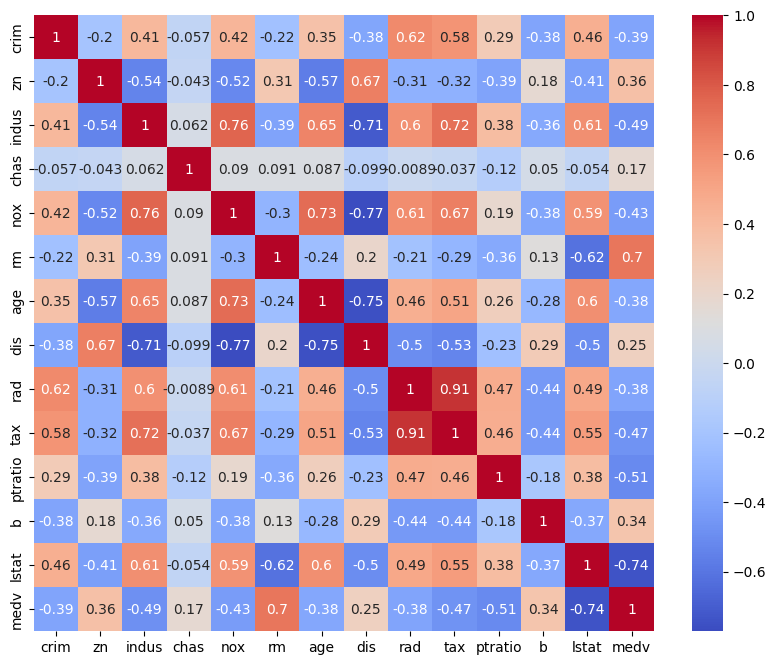

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot =True, cmap ="coolwarm")
plt.show()

#split features and target
in boston hosing target = MEDV (price)

In [15]:
x=df.drop("medv", axis =1)
y=df["medv"]

#Train test split

In [16]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(
    x,y,test_size=0.2, random_state =42
)

In [17]:
x_train

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat
391,5.29305,0.0,18.10,0,0.700,6.051,82.5,2.1678,24,666,20.2,378.38,18.76
20,1.25179,0.0,8.14,0,0.538,5.570,98.1,3.7979,4,307,21.0,376.57,21.02
327,0.24103,0.0,7.38,0,0.493,6.083,43.7,5.4159,5,287,19.6,396.90,12.79
337,0.03041,0.0,5.19,0,0.515,5.895,59.6,5.6150,5,224,20.2,394.81,10.56
58,0.15445,25.0,5.13,0,0.453,6.145,29.2,7.8148,8,284,19.7,390.68,6.86
...,...,...,...,...,...,...,...,...,...,...,...,...,...
110,0.10793,0.0,8.56,0,0.520,6.195,54.4,2.7778,5,384,20.9,393.49,13.00
275,0.09604,40.0,6.41,0,0.447,6.854,42.8,4.2673,4,254,17.6,396.90,2.98
353,0.01709,90.0,2.02,0,0.410,6.728,36.1,12.1265,5,187,17.0,384.46,4.50
440,22.05110,0.0,18.10,0,0.740,5.818,92.4,1.8662,24,666,20.2,391.45,22.11


#standardizing

In [18]:
#standardizing the dataseet to get improved output
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


In [20]:
x_train = scaler.fit_transform(x_train)


In [21]:
x_test =scaler.transform(x_test)

In [22]:
x_train

array([[ 0.22229375, -0.50209736,  1.01227379, ...,  0.8192869 ,
         0.22652076,  0.90909809],
       [-0.28565484, -0.50209736, -0.43955816, ...,  1.18601205,
         0.20602027,  1.23469959],
       [-0.41269792, -0.50209736, -0.55034052, ...,  0.54424304,
         0.43628265,  0.0489915 ],
       ...,
       [-0.44084509,  3.33436765, -1.33164767, ..., -0.64761369,
         0.29538427, -1.14536088],
       [ 2.32862391, -0.50209736,  1.01227379, ...,  0.8192869 ,
         0.37455466,  1.39173747],
       [-0.4214749 , -0.50209736, -0.37833633, ...,  1.14017141,
         0.42235138,  0.89469095]])

In [ ]:
#scaler.inverse_transform to get previous values of x_train

#Linear Regression Model

crossvalidation is to divide internal data and then cros valitdate the data then later we combine them and find their mean

In [23]:
from sklearn.linear_model import LinearRegression
##cross validation
from sklearn.model_selection import cross_val_score

In [33]:
regression= LinearRegression()
regression.fit(x_train,y_train)

LinearRegression()

In [34]:
mse=cross_val_score(regression,x_train,y_train,scoring ='neg_mean_squared_error',cv=5)

these are the cross validated data

In [35]:
np.mean(mse)

np.float64(-25.858569294636567)

mse must be least its diff btw predicted and actual values

#prediction

In [36]:
reg_pred=regression.predict(x_test)

In [37]:
reg_pred

array([10.18296392, 22.90028638, 15.7250715 , 32.8687425 , 23.06305477,
       11.7105764 , 12.82823273, 19.68402832, 21.37844603, 11.6664091 ,
       18.68922207, 30.07985757, -1.00929105, 25.84534881,  2.71769491,
        8.42105272, 24.20065448, 18.58158855, 25.35750486, -6.4156406 ,
       13.40087749, 19.1553702 , 26.97331835, 19.7365225 , 22.34723932,
       16.49474319, 28.88299512, 25.84032247, 18.44473853, 21.44179917,
       20.47924119, 30.65762986, 18.03142754, 31.7042724 , 31.32197253,
       22.39925592,  7.89877816, 23.82379177,  8.79518229, 24.80967266,
       13.11828624, 36.50280369, 14.21716209, 30.64314489, 13.08150701,
       28.62892717, 30.41900005, 20.22002346, 18.50467142, 13.74969166,
       24.00007979, 33.05373811, 16.31792202, 11.83136693, 34.38516527,
       33.21409913, 17.58969598, 18.73951491, 15.77944095, 27.36843691,
       20.56962491, 41.00811461, 20.7069354 ,  7.90355031, 26.05404575,
       28.09290827, 11.99510305,  7.63645472, 27.23768211, 16.49

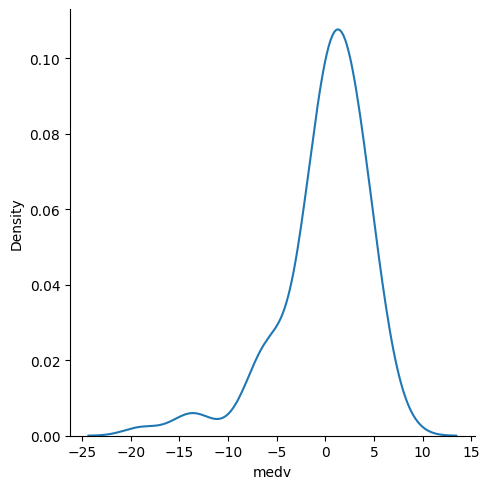

In [39]:
import seaborn as sns
sns.displot(reg_pred-y_test,kind='kde')# subtracting to know actual pediction

btw -10 to 10 most of

In [40]:
from sklearn.metrics import r2_score

In [41]:
score= r2_score(reg_pred,y_test)

In [42]:
score

0.7339863942058857

73% accuracyy

#Ridge Regression Algorithm

In [44]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

In [45]:
ridge_regressor=Ridge()

In [46]:
ridge_regressor

Ridge()

In [51]:
parameters={'alpha':[1,2,5,10,20,30,40,50,60,70,80,90]}
ridgecv=GridSearchCV(ridge_regressor,parameters,scoring ='neg_mean_squared_error',cv=5)
ridgecv.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [1, 2, 5, 10, 20, 30, 40, 50, 60, 70, 80,
                                   90]},
             scoring='neg_mean_squared_error')

In [53]:
print(ridgecv.best_params_)

{'alpha': 5}


In [54]:
print(ridgecv.best_score_)

-25.809007629778893


In [58]:
ridge_pred = ridgecv.best_estimator_.predict(x_test)

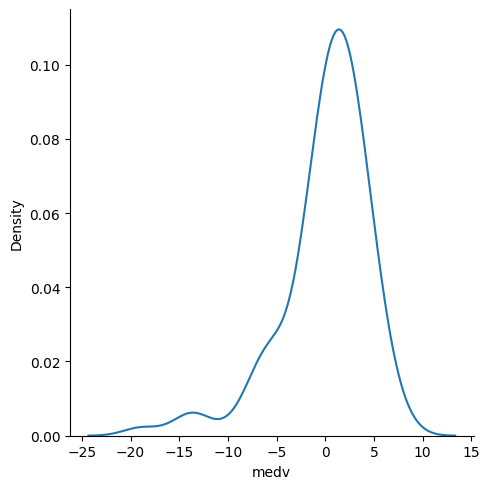

In [59]:
import seaborn as sns
sns.displot(ridge_pred-y_test,kind='kde')

In [60]:
score=r2_score(ridge_pred,y_test)

In [61]:
score

0.7309582087369086

##Lasso Regression Algorithm (automatic feature selection)

In [63]:
##Lasso Regresssion
from sklearn.linear_model import Lasso

In [66]:
lasso=Lasso()

In [67]:
parameters={'alpha':[1,2,5,10,20,30,40,50,60,70,80,90]}
lassocv=GridSearchCV(lasso,parameters,scoring ='neg_mean_squared_error',cv=5)
lassocv.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': [1, 2, 5, 10, 20, 30, 40, 50, 60, 70, 80,
                                   90]},
             scoring='neg_mean_squared_error')

In [68]:
print(lassocv.best_params_)
print(lassocv.best_score_)


{'alpha': 1}
-30.61687981437525


In [69]:
lasso_pred = lassocv.best_estimator_.predict(x_test)

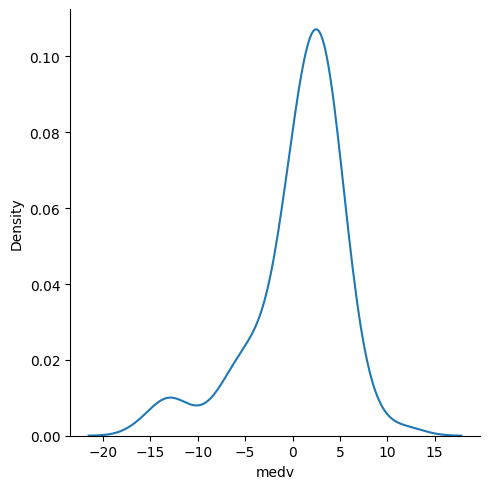

In [70]:
import seaborn as sns
sns.displot(lasso_pred-y_test,kind='kde')

In [71]:
score=r2_score(lasso_pred,y_test)

In [72]:
score

0.5197582022943821